In [ ]:
import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.plotting import plot
from deepinv.loss.metric import SSIM, MSE, PSNR, LPIPS
import deepinv as dinv
from deepinv.utils.plotting import plot
from tqdm import tqdm

import torch.nn as nn
import matplotlib.pyplot as plt

dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

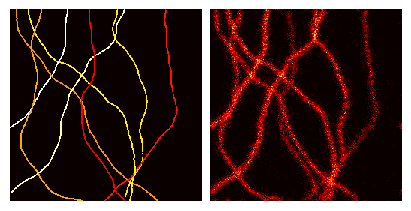

In [ ]:
# load a 2D PSFs for 25 detectors 
image = torch.load("tub_level.pth")
PSF = torch.load("PSF_torch.pth")
flux = 20
Nx = 256

## DEFINE OPERATORS------------------------------
physics_blurr = dinv.physics.BlurFFT(img_size = (1, 1, Nx, Nx), filter = PSF, device=device)
physics_noise = Denoising()
physics_noise.noise_model = PoissonNoise(gain = 1.0)

## COMPUTE FINGERPRINT FOR BACKGROUND
x_center = PSF[12:13].sum()
index = torch.zeros(25, device = device)
finger_print = torch.zeros(25, device = device)
for j in range(0,25):
    finger_print[j] = PSF[j:j+1].sum()
    index[j] = finger_print[j]/x_center.to(device)
back_vec = index * 1e-3

ground_truth = flux * image.to(device)
clean_image = physics_blurr(ground_truth.repeat(25,1,1,1))
clean_image = clean_image + back_vec.view(25,1,1,1)        # add background
noise_image = physics_noise(clean_image)
    
# Initial vector
x_0 = physics_blurr.A_adjoint(noise_image)           
x_0 = x_0.sum(0).unsqueeze(0)


plot([ground_truth, noise_image.sum(0)], cmap = 'hot')



100%|██████████| 10/10 [00:00<00:00, 2482.57it/s]


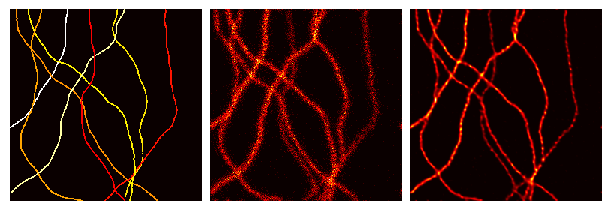

In [15]:
max_iter = 10
x_curr = x_0
for k in tqdm(range(max_iter)):
    x_next = (physics_blurr.A_adjoint(noise_image / (physics_blurr(x_curr) + back_vec.view(25,1,1,1)))) * x_curr
    x_next = x_next.sum(0).unsqueeze(0)
    x_curr = x_next
    
    
plot([ground_truth, noise_image.sum(0), x_next], cmap = 'hot')
